In [1]:
import argparse
import json
import logging
import os
import shutil
import sys
from pathlib import Path
from tqdm import tqdm
import torch
import yaml
from monai.utils import set_determinism
from sklearn.preprocessing import StandardScaler

from src.data.data_loader import get_dataloader
from src.model.cspca_model import CSPCAModel
from src.model.mil import MILModel3D
from src.train.train_cspca import train_epoch, val_epoch
from src.utils import get_metrics, save_cspca_checkpoint, setup_logging
import nrrd
import matplotlib.pyplot as plt

In [3]:
import json
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca_updated_with_psa.json', 'r') as f:
    train_data = json.load(f)

In [4]:
len(train_data['train'])

624

In [5]:
len(train_data['test'])

152

In [1]:
import json
import os
import numpy as np

In [2]:
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PI-RADS_data_updated.json', 'r') as f:
    data = json.load(f)
    
print(len(data['train']))
print(len(data['test']))


6011
671


In [3]:
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/cspca_train_tcia_updated_vol.json', 'r') as f:
    data = json.load(f)
    
print(len(data['train']))



379


In [ ]:
/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca_updated_with_psa_updated_vol.json

In [10]:
dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed'
files = os.listdir(os.path.join(dir, 't2_registered'))
file  = files[1]
t2, _ = nrrd.read(os.path.join(dir, 't2_registered', file))
adc, _ = nrrd.read(os.path.join(dir, 'ADC_registered', file))
dwi, _ = nrrd.read(os.path.join(dir, 'DWI_registered', file))
heats, _ = nrrd.read(os.path.join(dir, 'heatmaps', file))
seg, _ = nrrd.read(os.path.join(dir, 'prostate_mask', file))

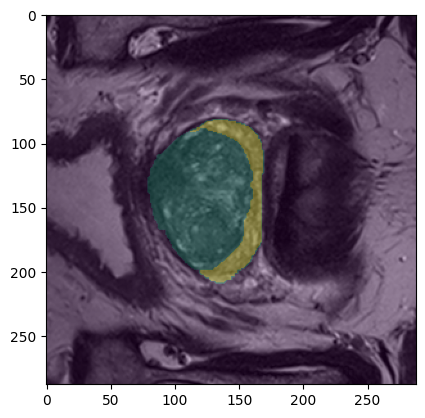

In [11]:
plt.imshow(t2[:,:,12], cmap='grey')

plt.imshow(seg[:,:,12], cmap='viridis', alpha=0.3)


In [2]:
import os
import pandas as pd

In [4]:

df = pd.read_csv('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/marksheet.csv')
df.head()

,patient_id,study_id,mri_date,patient_age,psa,psad,prostate_volume,histopath_type,lesion_GS,lesion_ISUP,case_ISUP,case_csPCa,center
0,10000,1000000,2019-07-02,73,7.7,NaN,55.0,MRBx,0+0,0,0,NO,PCNN
1,10001,1000001,2016-05-27,64,8.7,0.09,102.0,NaN,NaN,NaN,0,NO,RUMC
2,10002,1000002,2021-04-18,58,4.2,0.06,74.0,NaN,NaN,NaN,0,NO,ZGT
3,10003,1000003,2019-04-05,72,13.0,NaN,71.5,SysBx,0+0,0,0,NO,ZGT
4,10004,1000004,2020-10-21,67,8.0,0.10,78.0,SysBx+MRBx,"0+0,0+0","0,0",0,NO,RUMC


In [6]:
df['psa'].count()

1460

In [11]:
print(len(df))
print(len(df[df['case_csPCa'] == 'NO']))
print(len(df[df['case_csPCa'] == 'YES']))

1500
1075
425


In [1]:
import os
import json
import numpy as np

In [6]:
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca_updated_test_with_psa.json', 'r') as f:
    picai_data = json.load(f)
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/cspca_train_tcia.json', 'r') as f:
    tcia_data = json.load(f)

In [7]:
data_new = {}
data_new['train'] = picai_data['test']
data_new['test'] = tcia_data['test']

In [8]:
for i,j in enumerate(data_new['train']):
    data_new['train'][i]['image'] = os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/t2_registered', j['image']) 

In [9]:
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/godknows.json', 'w') as f:
    json.dump(data_new, f, indent=4)